# Evaluation of all Off-Target-Models

In [ ]:
# IMPORTS

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from mypackage.config import *
from mypackage.utils import *

In [2]:
# LOADING MODELS WITH DATA

model_names = ("rf_v1.0", "lr_v1.0", "xgb_v1.0")
models = {}

for model_name in model_names:

    model = load_model(model_name, MODELS_OFFTARGET_OLD)
    df_data = pd.read_pickle(DATA_PROCESSED_OFFTARGET_OLD / f"{model.dataset_id}")
    models.update({model_name: [model, df_data]})

Model loaded from /Users/thewildchip/Desktop/Coding/crispr-genie-lab-jf/models/off_target_old/rf_v1.0.joblib
Model loaded from /Users/thewildchip/Desktop/Coding/crispr-genie-lab-jf/models/off_target_old/lr_v1.0.joblib
Model loaded from /Users/thewildchip/Desktop/Coding/crispr-genie-lab-jf/models/off_target_old/xgb_v1.0.joblib


In [3]:
# MODEL EVALUATION AS DICT
all_evaluations = {}
for model_name, (model, model_df) in models.items():
    _, val_X, _, val_y = load_data(model_df, "label")
    y_pred = model.predict(val_X)
    all_evaluations[model_name] = evaluate_model_classification(val_y, y_pred)

all_evaluations

{'rf_v1.0': {'Acc': 0.9998956485442972,
  'Prec': 1.0,
  'F1': 0.8888888888888888,
  'Recall': 0.8},
 'lr_v1.0': {'Acc': 0.9996869456328916,
  'Prec': 1.0,
  'F1': 0.5714285714285714,
  'Recall': 0.4},
 'xgb_v1.0': {'Acc': 0.9998434728164458,
  'Prec': 1.0,
  'F1': 0.8235294117647058,
  'Recall': 0.7}}

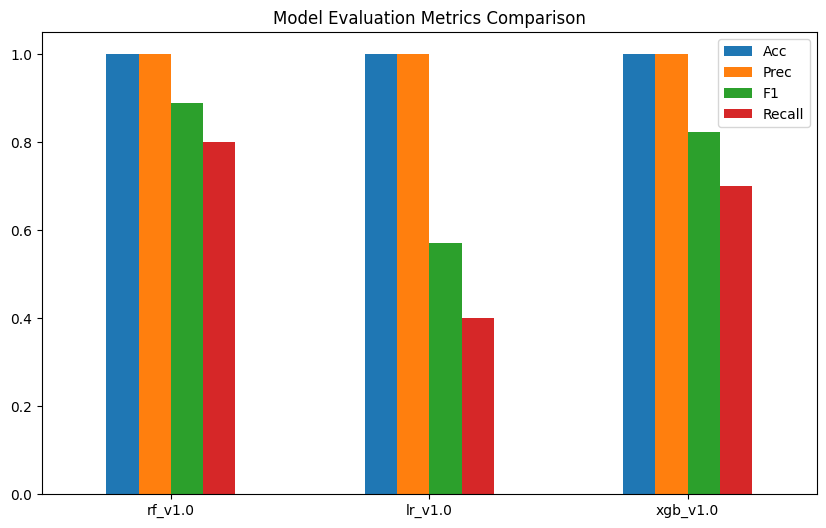

In [4]:
df_res = pd.DataFrame.from_dict(all_evaluations, orient='index')
df_res.plot.bar(rot=0, figsize=(10,6), title="Model Evaluation Metrics Comparison")
# sns.heatmap(df_res, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Metric Value'})
# plt.title("Model Evaluation Metrics Heatmap")
plt.show()